# Split aleatório vs. split temporal — auditoria de vazamento

Tráfego de rede é **sequencial**: pacotes da mesma rajada de ataque são correlacionados. Um
`train_test_split` **aleatório** pode colocar pacotes da mesma rajada em treino **e** teste,
inflando as métricas (*vazamento temporal*). Este notebook compara, no mesmo modelo:

- **Aleatório 70/30** (estratificado) — o original;
- **Temporal por arquivo 70/30** — primeiros 70% (cronológicos) de **cada PCAP** para treino,
  últimos 30% para teste (sem vazamento de continuidade);
- referência: **zero-day** (leave-one-attack-out, em `someip-ids-benchmark`) — o teste mais duro.

> As features (`data/ours_ext/X.npz`) estão na **ordem de extração**: arquivos concatenados,
> cada um em ordem de pacote. As fronteiras dos 7 arquivos vêm das contagens da extração.

In [1]:
import os
# normaliza o cwd para a raiz do repo (onde existe data/ours_ext/X.npz)
if not os.path.exists('data/ours_ext/X.npz'):
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')                                  # rodando de dentro de notebooks/
    elif os.path.isdir('someip-ids-multiclass-contentext'):
        os.chdir('someip-ids-multiclass-contentext')    # Colab: repo já clonado
    else:                                               # Colab: clona e baixa features (LFS)
        os.system('git clone -q https://github.com/GuilhermeFrick/someip-ids-multiclass-contentext.git')
        os.chdir('someip-ids-multiclass-contentext')
        os.system('git lfs install && git lfs pull')
print('cwd:', os.getcwd(), '| data ok:', os.path.exists('data/ours_ext/X.npz'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier

CLASSES = ['normal','dos','fuzzy','mitm_single','mitm_multi']; N=len(CLASSES); SEED=0
CONTENT_EXT = list(range(12)) + [12, 13, 14, 16]
FILE_COUNTS = [('benign',2193802),('dos',1864530),('fuzzy1',2197113),('fuzzy2',1304154),
               ('fuzzy3',2223650),('mitm_multi',2412529),('mitm_single',2037576)]

X = np.load('data/ours_ext/X.npz')['a'][:, CONTENT_EXT]
y = np.load('data/ours_ext/y_multi.npz')['a']
print('X:', X.shape)

def xgb():
    return XGBClassifier(objective='multi:softprob', num_class=N, n_estimators=300, max_depth=8,
                         learning_rate=0.3, tree_method='hist', max_bin=256, n_jobs=-1, eval_metric='mlogloss')

def per_class(y_te, y_pred):
    r = classification_report(y_te, y_pred, target_names=CLASSES, digits=4, output_dict=True)
    return {c: r[c]['f1-score'] for c in CLASSES} | {'macro_f1': r['macro avg']['f1-score']}

cwd: C:\Mestrado\someip-ids-multiclass-contentext | data ok: True


X: (14233354, 16)


In [2]:
# Split ALEATÓRIO (o original)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
m = xgb(); m.fit(Xtr, ytr)
rand = per_class(yte, m.predict(Xte))
print('aleatório macro-F1:', round(rand['macro_f1'], 4))

aleatório macro-F1: 0.9936


In [3]:
# Split TEMPORAL POR ARQUIVO (primeiros 70% / últimos 30% de cada PCAP)
tr, te, start = [], [], 0
for _, cnt in FILE_COUNTS:
    cut = start + int(cnt * 0.7)
    tr.append(np.arange(start, cut)); te.append(np.arange(cut, start + cnt)); start += cnt
itr, ite = np.concatenate(tr), np.concatenate(te)
print('teste temporal — classes:', {CLASSES[c]: int((y[ite]==c).sum()) for c in range(N)})
m2 = xgb(); m2.fit(X[itr], y[itr])
temp = per_class(y[ite], m2.predict(X[ite]))
print('temporal macro-F1:', round(temp['macro_f1'], 4))

teste temporal — classes: {'normal': 3780722, 'dos': 99940, 'fuzzy': 170209, 'mitm_single': 94360, 'mitm_multi': 124777}


temporal macro-F1: 0.9658


,normal,dos,fuzzy,mitm_single,mitm_multi,macro_f1
aleatório,0.9995,0.9909,0.9979,0.9911,0.9889,0.9936
temporal,0.9938,0.9979,0.9979,0.9916,0.8477,0.9658


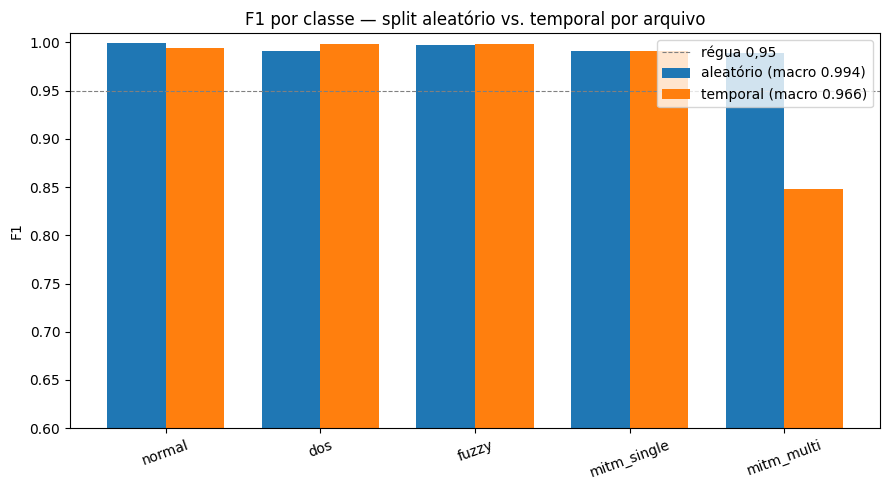

In [4]:
# Comparação
df = pd.DataFrame({'aleatório': rand, 'temporal': temp}).T[CLASSES + ['macro_f1']]
display(df.round(4))

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(N); w = 0.38
ax.bar(x - w/2, [rand[c] for c in CLASSES], w, label=f"aleatório (macro {rand['macro_f1']:.3f})")
ax.bar(x + w/2, [temp[c] for c in CLASSES], w, label=f"temporal (macro {temp['macro_f1']:.3f})")
ax.axhline(0.95, ls='--', c='gray', lw=0.8, label='régua 0,95')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=20); ax.set_ylim(0.6, 1.01)
ax.set_ylabel('F1'); ax.set_title('F1 por classe — split aleatório vs. temporal por arquivo')
ax.legend(); plt.tight_layout(); plt.show()

## Conclusão

| Split | macro-F1 |
|---|---:|
| Aleatório (otimista) | **0,9936** |
| **Temporal por arquivo** (honesto) | **0,9658** |
| Zero-day / leave-one-attack-out (ataque novo) | ~0,60 |

- **Há vazamento temporal no split aleatório**, sim — o número cai ~2,8 pontos no split temporal.
- **Mas a queda é modesta, não um colapso:** o modelo mantém **0,966 > 0,95** (nível de produção).
  A única classe que cai forte é **mitm_multi** (0,989→0,848) — a do *relay*, mais dependente de
  estrutura temporal.
- **O teste mais duro (ataque nunca visto)** continua sendo o **zero-day (~0,60)** — esse é o
  limite real de generalização, já reportado no `someip-ids-benchmark`.
- **Recomendação para a dissertação:** reportar o **temporal** como número in-scope honesto e o
  **zero-day** como generalização — o aleatório fica só como ilustração do viés.